In [12]:
import pandas as pd
import numpy as np 

data = pd.read_csv("./DataSpline.csv")
data = data.drop(columns=["x(Wd,We)", "y(Wd,We)", "tempo"])

data

,Wd,We,"theta(Wd,We)"
0,0.006601,-0.004670,0.013946
1,-0.013306,0.003222,0.013924
2,-0.003845,0.005068,0.013897
3,0.013886,0.002956,0.013866
4,0.018786,-0.001023,0.013831
...,...,...,...
2141,-1.538379,-1.890715,-0.804489
2142,-2.207216,-2.490244,-0.802587
2143,-2.382927,-2.292476,-0.800544
2144,-2.615423,-2.555254,-0.798358


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

# Scale our data to have mean 0
scaler = StandardScaler()
data[PREDICTORS] = scaler.fit_transform(data[PREDICTORS])

# Split into train (70%), validation (15%), and test (15%) sets
train_data, temp_data = train_test_split(data, test_size=0.3, shuffle=False)
valid_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

# Convertendo para arrays numpy
train_x = train_data[PREDICTORS].to_numpy()
train_y = train_data[[TARGET]].to_numpy()

x_val = valid_data[PREDICTORS].to_numpy()
y_val = valid_data[[TARGET]].to_numpy()

x_test = test_data[PREDICTORS].to_numpy()
y_test = test_data[[TARGET]].to_numpy()


In [15]:
import matplotlib.pyplot as plt
import keras

def compile_model(model, epochs=100):
    # Compilando o modelo
    model.compile(loss="mse", optimizer="adam")

    # Treinando o modelo
    history = model.fit(train_x, train_y, epochs=epochs, validation_data=(x_val, y_val), verbose=False)

    # Avaliando o modelo
    mse_v = model.evaluate(x_val, y_val)
    print(f"Validation MSE: {mse_v:.4f}")
    
    mse_t = model.evaluate(x_test, y_test)
    print(f"Teste MSE: {mse_t:.4f}")

    # Plotando o histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()


In [16]:
model_RNA = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[3, 1]),
        keras.layers.Dense(1)
])
model_RNN = keras.models.Sequential([
        keras.layers.SimpleRNN(1, input_shape=[3, 1])
])

complex_RNN = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20, return_sequences=True),
        keras.layers.SimpleRNN(1)
])

complex_dense_RNN  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])

simple_dense_RNN  = keras.models.Sequential([
        keras.layers.SimpleRNN(1, return_sequences=True, input_shape=[2, 1]),
        keras.layers.Dense(1)
])

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4439     
Validation MSE: 0.7610
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4232 
Teste MSE: 1.5707


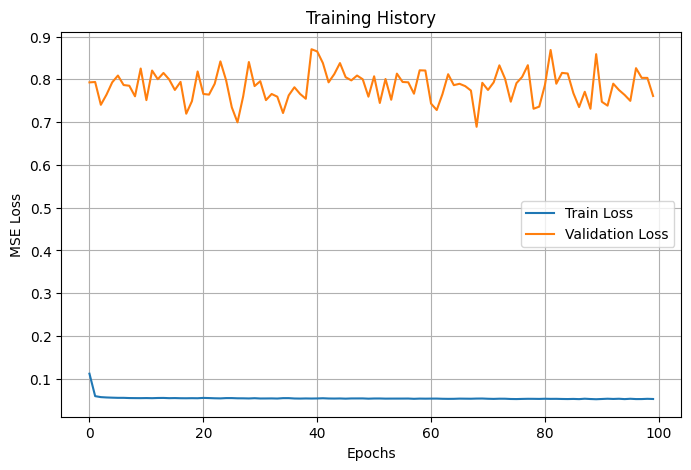

In [18]:
compile_model(complex_dense_RNN)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4318     
Validation MSE: 0.7692
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5789 
Teste MSE: 1.7365


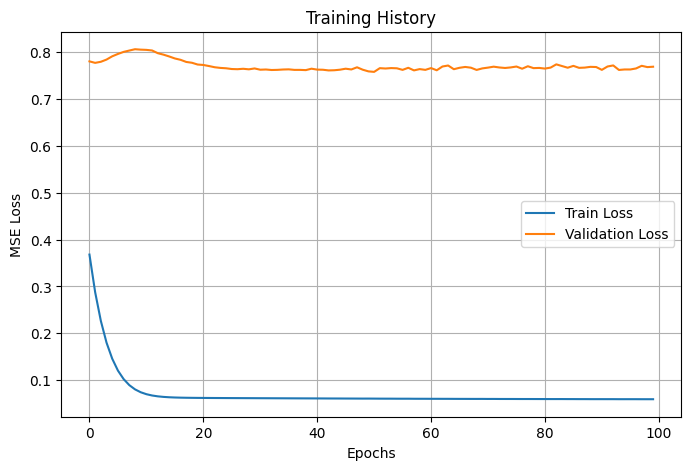

In [19]:
compile_model(simple_dense_RNN)

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4157 
Validation MSE: 0.7503
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5820 
Teste MSE: 1.7402


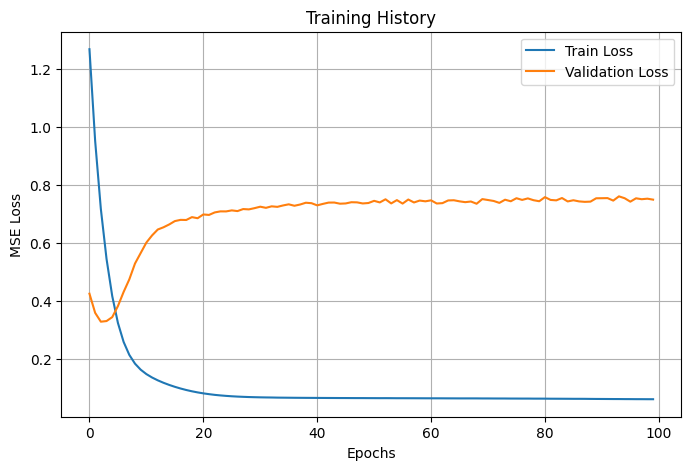

In [20]:
simple_dense_RNN  = keras.models.Sequential([
            keras.layers.SimpleRNN(2, return_sequences=True, input_shape=[3, 1]),
            keras.layers.Dense(1)
    ])
compile_model(simple_dense_RNN)

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4485     
Validation MSE: 0.7826
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5427 
Teste MSE: 1.6970


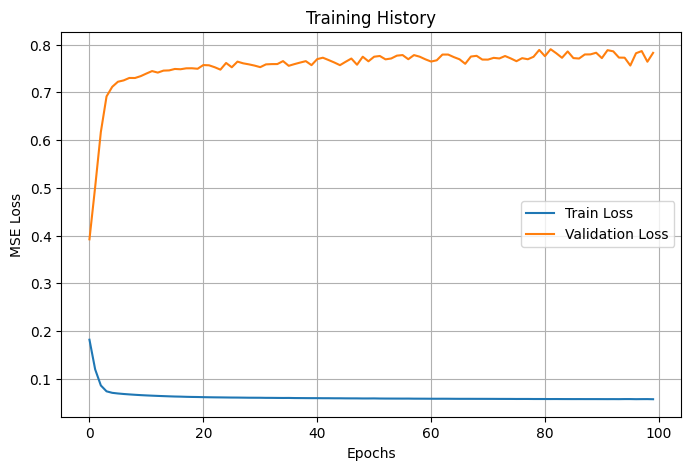

In [21]:
simple_dense_RNN  = keras.models.Sequential([
            keras.layers.SimpleRNN(3, return_sequences=True, input_shape=[3, 1]),
            keras.layers.Dense(1)
    ])
compile_model(simple_dense_RNN)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4449     
Validation MSE: 0.7690
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4929 
Teste MSE: 1.6443


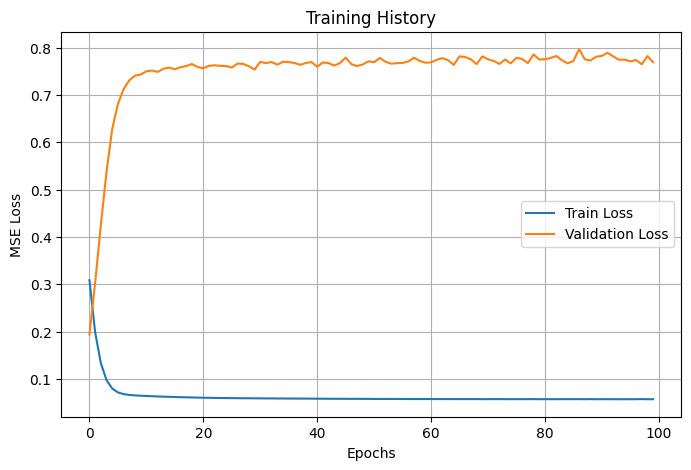

In [22]:
simple_dense_RNN  = keras.models.Sequential([
            keras.layers.SimpleRNN(4, return_sequences=True, input_shape=[3, 1]),
            keras.layers.Dense(1)
    ])
compile_model(simple_dense_RNN)